In [1]:
import sys
!{sys.executable} -m pip install -q datasets scikit-learn torch transformers matplotlib pandas numpy tqdm
print("Done.")

Done.


In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from transformers import pipeline as hf_pipeline
from datasets import load_dataset, disable_progress_bar
from IPython.display import display

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
disable_progress_bar()
warnings.filterwarnings("ignore")
print("Ready.")

Ready.


In [3]:
SAMPLE_SIZE = 2000
SEED = 42

# Social media
ds = load_dataset("tweet_eval", "sentiment")
df_social = ds["train"].to_pandas()
df_social = df_social[df_social["label"] != 1].copy()
df_social["label"] = df_social["label"].map({0: 0, 2: 1})
df_social = df_social[["text", "label"]].sample(SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)

# Product reviews
ds = load_dataset("amazon_polarity", trust_remote_code=True)
df_reviews = ds["test"].to_pandas()[["content", "label"]]
df_reviews = df_reviews.rename(columns={"content": "text"}).sample(SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)

# News / formal
ds = load_dataset("glue", "sst2")
df_news = ds["train"].to_pandas()[["sentence", "label"]]
df_news = df_news.rename(columns={"sentence": "text"}).sample(SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)

for name, df in [("Social media", df_social), ("Product reviews", df_reviews), ("News/formal", df_news)]:
    print(f"{name}: {df.shape} | {df['label'].value_counts().to_dict()}")

Social media: (2000, 2) | {1: 1459, 0: 541}
Product reviews: (2000, 2) | {1: 1024, 0: 976}
News/formal: (2000, 2) | {1: 1114, 0: 886}


In [4]:
def run_naive_bayes(df, name):
    print(f"\nNaive Bayes on {name}")
    X_train, X_test, y_train, y_test = train_test_split(
        df["text"], df["label"], test_size=0.2, random_state=42)
    model = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
        ("nb",    MultinomialNB())
    ])
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(classification_report(y_test, preds, target_names=["Negative", "Positive"]))
    return y_test.tolist(), preds.tolist()

nb_results = {}
for name, df in [("Social media", df_social), ("Product reviews", df_reviews), ("News/formal", df_news)]:
    nb_results[name] = run_naive_bayes(df, name)


Naive Bayes on Social media
              precision    recall  f1-score   support

    Negative       1.00      0.02      0.03       116
    Positive       0.71      1.00      0.83       284

    accuracy                           0.71       400
   macro avg       0.86      0.51      0.43       400
weighted avg       0.80      0.71      0.60       400


Naive Bayes on Product reviews
              precision    recall  f1-score   support

    Negative       0.79      0.84      0.81       182
    Positive       0.86      0.82      0.84       218

    accuracy                           0.82       400
   macro avg       0.82      0.83      0.82       400
weighted avg       0.83      0.82      0.83       400


Naive Bayes on News/formal
              precision    recall  f1-score   support

    Negative       0.80      0.45      0.57       181
    Positive       0.67      0.91      0.77       219

    accuracy                           0.70       400
   macro avg       0.73      0.68      

In [5]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=100):
        self.labels = labels
        self.data   = [[vocab.get(w, 1) for w in t.lower().split()][:max_len] for t in texts]
    def __len__(self): return len(self.data)
    def __getitem__(self, i):
        x = self.data[i] + [0] * (100 - len(self.data[i]))
        return torch.tensor(x), torch.tensor(self.labels[i])

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden=128):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm  = nn.LSTM(embed_dim, hidden, batch_first=True, bidirectional=True)
        self.fc    = nn.Linear(hidden * 2, 2)
    def forward(self, x):
        x = self.embed(x)
        _, (h, _) = self.lstm(x)
        h = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(h)

def run_bilstm(df, name, epochs=5):
    print(f"\nBiLSTM on {name}")
    texts, labels = df["text"].tolist(), df["label"].tolist()
    split = int(len(texts) * 0.8)

    vocab = {w: i+2 for i, (w, _) in enumerate(
        Counter(w for t in texts[:split] for w in t.lower().split()).most_common(20000)
    )}

    train_dl = DataLoader(TextDataset(texts[:split], labels[:split], vocab), batch_size=64, shuffle=True)
    test_dl  = DataLoader(TextDataset(texts[split:], labels[split:], vocab), batch_size=64)

    model   = BiLSTM(len(vocab) + 2)
    opt     = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for X, y in train_dl:
            opt.zero_grad()
            loss_fn(model(X), y).backward()
            opt.step()
        print(f"  Epoch {epoch+1}/{epochs}")

    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X, y in test_dl:
            preds += model(X).argmax(1).tolist()
            trues += y.tolist()
    print(classification_report(trues, preds, target_names=["Negative", "Positive"]))
    return trues, preds

lstm_results = {}
for name, df in [("Social media", df_social), ("Product reviews", df_reviews), ("News/formal", df_news)]:
    lstm_results[name] = run_bilstm(df, name)


BiLSTM on Social media
  Epoch 1/5
  Epoch 2/5
  Epoch 3/5
  Epoch 4/5
  Epoch 5/5
              precision    recall  f1-score   support

    Negative       0.56      0.45      0.50       110
    Positive       0.81      0.86      0.83       290

    accuracy                           0.75       400
   macro avg       0.68      0.66      0.67       400
weighted avg       0.74      0.75      0.74       400


BiLSTM on Product reviews
  Epoch 1/5
  Epoch 2/5
  Epoch 3/5
  Epoch 4/5
  Epoch 5/5
              precision    recall  f1-score   support

    Negative       0.69      0.45      0.54       209
    Positive       0.56      0.77      0.65       191

    accuracy                           0.60       400
   macro avg       0.62      0.61      0.60       400
weighted avg       0.63      0.60      0.60       400


BiLSTM on News/formal
  Epoch 1/5
  Epoch 2/5
  Epoch 3/5
  Epoch 4/5
  Epoch 5/5
              precision    recall  f1-score   support

    Negative       0.57      0.49    

In [6]:
def run_roberta(df, name):
    print(f"\nRoBERTa on {name}")
    clf = hf_pipeline("sentiment-analysis",
                      model="cardiffnlp/twitter-roberta-base-sentiment-latest",
                      truncation=True, max_length=512, device=-1)
    texts = df["text"].tolist()
    labels = df["label"].tolist()
    preds = []
    for i in range(0, len(texts), 64):
        results = clf(texts[i:i+64])
        preds  += [1 if r["label"] == "positive" else 0 for r in results]
        print(f"  {min(i+64, len(texts))}/{len(texts)}", end="\r")
    print(classification_report(labels, preds, target_names=["Negative", "Positive"]))
    return labels, preds

roberta_results = {}
for name, df in [("Social media", df_social), ("Product reviews", df_reviews), ("News/formal", df_news)]:
    roberta_results[name] = run_roberta(df, name)


RoBERTa on Social media


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


              precision    recall  f1-score   support

    Negative       0.63      0.98      0.76       541
    Positive       0.99      0.78      0.87      1459

    accuracy                           0.84      2000
   macro avg       0.81      0.88      0.82      2000
weighted avg       0.89      0.84      0.84      2000


RoBERTa on Product reviews


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


              precision    recall  f1-score   support

    Negative       0.85      0.91      0.88       976
    Positive       0.90      0.85      0.88      1024

    accuracy                           0.88      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.88      0.88      0.88      2000


RoBERTa on News/formal


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


              precision    recall  f1-score   support

    Negative       0.60      0.98      0.74       886
    Positive       0.97      0.47      0.64      1114

    accuracy                           0.70      2000
   macro avg       0.79      0.73      0.69      2000
weighted avg       0.81      0.70      0.69      2000



In [7]:
rows = []
for name in ["Social media", "Product reviews", "News/formal"]:
    for model_name, res in [("Naive Bayes", nb_results), ("BiLSTM", lstm_results), ("RoBERTa", roberta_results)]:
        y_true, y_pred = res[name]
        rows.append({
            "Dataset": name,
            "Model":   model_name,
            "Accuracy": round(accuracy_score(y_true, y_pred) * 100, 2),
            "F1":       round(f1_score(y_true, y_pred, average="weighted"), 3),
        })

summary = pd.DataFrame(rows)
display(summary)

,Dataset,Model,Accuracy,F1
0,Social media,Naive Bayes,71.50,0.601
1,Social media,BiLSTM,75.00,0.742
2,Social media,RoBERTa,83.65,0.845
3,Product reviews,Naive Bayes,82.50,0.825
4,Product reviews,BiLSTM,60.50,0.595
5,Product reviews,RoBERTa,87.75,0.877
6,News/formal,Naive Bayes,70.00,0.681
7,News/formal,BiLSTM,60.00,0.596
8,News/formal,RoBERTa,70.05,0.685


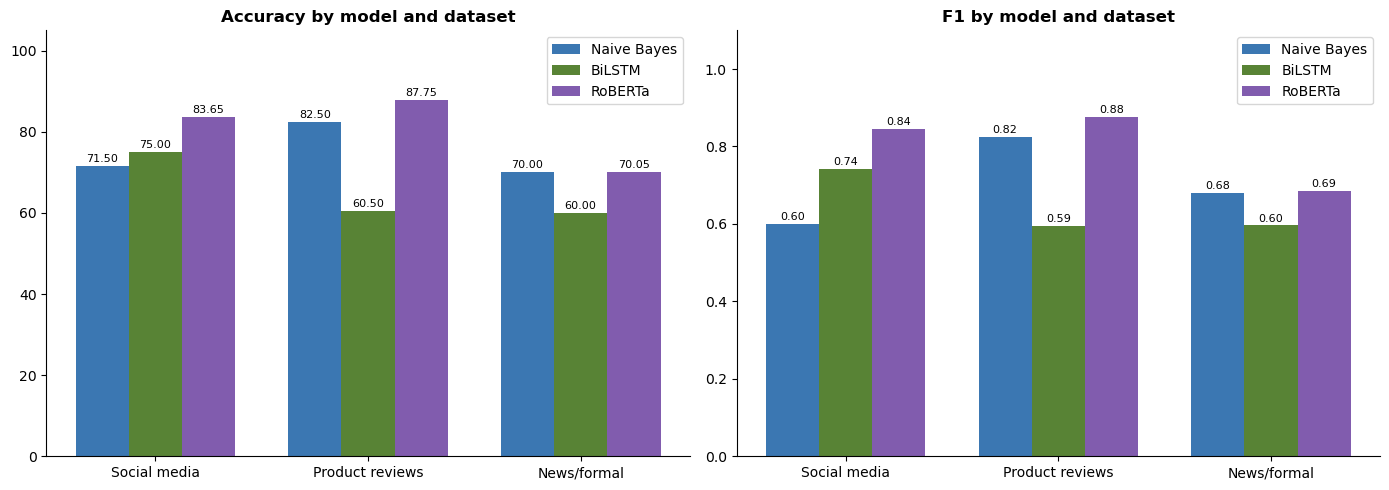

Saved as comparison.png


In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

colors   = {"Naive Bayes": "#185FA5", "BiLSTM": "#3B6D11", "RoBERTa": "#6B3FA0"}
datasets = ["Social media", "Product reviews", "News/formal"]
models   = ["Naive Bayes", "BiLSTM", "RoBERTa"]
x        = np.arange(len(datasets))
width    = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ["Accuracy", "F1"]):
    for i, model in enumerate(models):
        vals = [summary[(summary.Dataset == d) & (summary.Model == model)][metric].values[0] for d in datasets]
        bars = ax.bar(x + i * width, vals, width, label=model, color=colors[model], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.5 if metric == "Accuracy" else 0.005),
                    f"{v:.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x + width)
    ax.set_xticklabels(datasets)
    ax.set_title(f"{metric} by model and dataset", fontweight="bold")
    ax.set_ylim(0, 105 if metric == "Accuracy" else 1.1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend()

plt.tight_layout()
plt.savefig("comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as comparison.png")